In [3]:
# ### 1. 라이브러리 임포트 및 모델 학습

# %%
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, log_loss
from sklearn.tree import DecisionTreeClassifier

# 1. 데이터 불러오기
df = pd.read_csv(r"./data/train_features.csv")

# 2. 불필요한 컬럼 제거
drop_cols = [
    "msno",
    "is_churn",
    "last_tx_date",
    "last_expire_date",
    "last_listen_date"
]

X = df.drop(columns=drop_cols)
y = df["is_churn"]

# 3. 문자형 컬럼 더미화
X = pd.get_dummies(X, drop_first=False)

# 4. 결측치 처리
X = X.fillna(0)

# 5. train / validation 분리
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. Decision Tree 모델 생성
# XGBoost 대신 Decision Tree에 맞는 과적합 방지 파라미터 적용
dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42
)

# 7. 학습
dt_model.fit(X_train, y_train)

# 8. 예측
pred = dt_model.predict(X_val)
pred_proba = dt_model.predict_proba(X_val)[:, 1]

# 9. 평가
print("Confusion Matrix")
print(confusion_matrix(y_val, pred))

print("\nClassification Report")
print(classification_report(y_val, pred))

print("ROC-AUC:", roc_auc_score(y_val, pred_proba))
print("F1-score:", f1_score(y_val, pred))


Confusion Matrix
[[172220  13673]
 [   323  12371]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    185893
           1       0.48      0.97      0.64     12694

    accuracy                           0.93    198587
   macro avg       0.74      0.95      0.80    198587
weighted avg       0.96      0.93      0.94    198587

ROC-AUC: 0.989782433792681
F1-score: 0.638701017089163


In [4]:
# ### 2. 주요 평가지표 DataFrame 확인

# %%
result_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Score": [
        accuracy_score(y_val, pred),
        precision_score(y_val, pred),
        recall_score(y_val, pred),
        f1_score(y_val, pred),
        roc_auc_score(y_val, pred_proba)
    ]
})

result_df


,Metric,Score
0,Accuracy,0.929522
1,Precision,0.475004
2,Recall,0.974555
3,F1-Score,0.638701
4,ROC-AUC,0.989782


In [5]:
# ### 3. 예측 확률 결과 확인

# %%
result = pd.DataFrame({
    "Actual": y_val,
    "Predicted": pred,
    "Probability": pred_proba
})

result.head(20)



,Actual,Predicted,Probability
924393,0,1,0.584239
652521,0,0,0.002312
950495,0,0,0.002312
330087,0,0,0.002312
329247,0,0,0.002312
385904,0,0,0.002312
308951,0,0,0.002312
944790,0,0,0.002312
544017,0,1,0.604014
480741,0,0,0.424581


In [6]:
# ### 4. 피처 중요도 (Feature Importance) 시각화

# %%
# 중요도 추출
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

# 중요도 순 정렬 후 상위 10개 선택
top10 = (
    importance_df
    .sort_values("Importance", ascending=False)
    .head(10)
)


In [15]:
# 저장할 폴더 미리 만들기
os.makedirs("results", exist_ok=True)

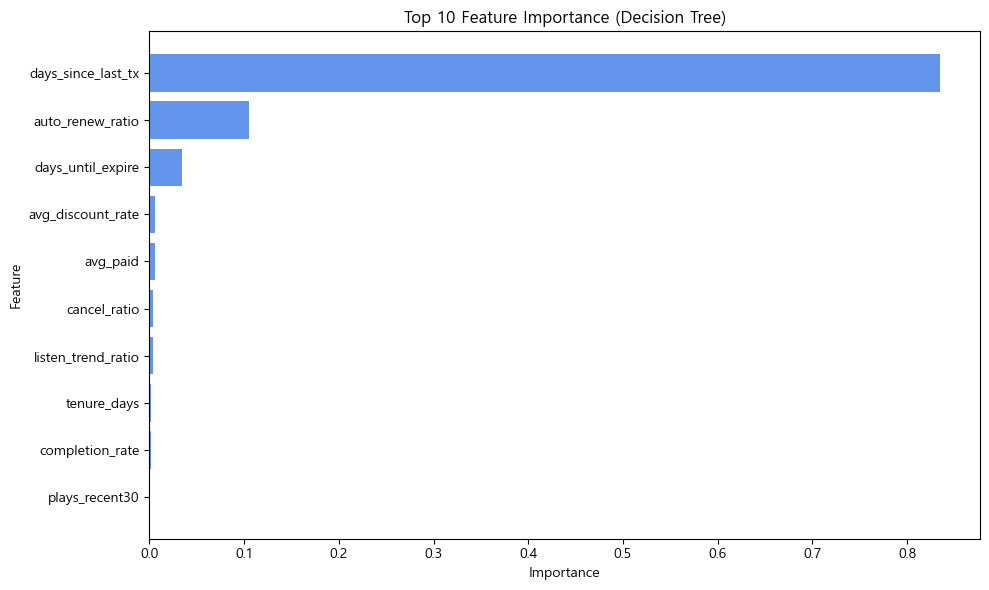

,Feature,Importance
14,days_since_last_tx,0.835146
9,auto_renew_ratio,0.104730
15,days_until_expire,0.033948
7,avg_discount_rate,0.006035
6,avg_paid,0.005896
10,cancel_ratio,0.004092
27,listen_trend_ratio,0.003959
0,tenure_days,0.001597
21,completion_rate,0.001497
25,plays_recent30,0.001116


In [16]:

# 그래프
plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"], top10["Importance"], color='cornflowerblue')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance (Decision Tree)")
plt.gca().invert_yaxis()  # 가장 중요한 변수가 위로 오게
plt.tight_layout()
plt.savefig("results/feature_importance_dt.png", dpi=300, bbox_inches='tight')
plt.show()

top10.head(20)


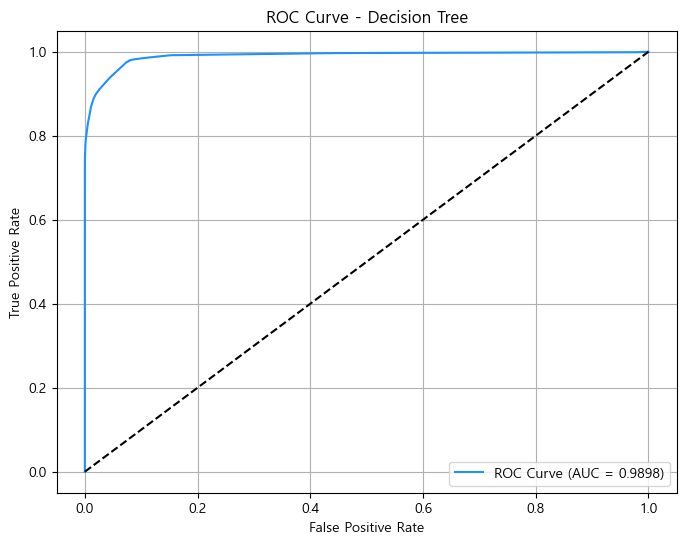

In [17]:

# ### 5. ROC Curve 시각화

# %%
# ROC Curve 계산
fpr, tpr, thresholds = roc_curve(y_val, pred_proba)

# AUC 계산
auc_score = roc_auc_score(y_val, pred_proba)

# 그래프
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    color='dodgerblue',
    label=f"ROC Curve (AUC = {auc_score:.4f})"
)

# 랜덤 모델 기준선
plt.plot([0, 1], [0, 1], linestyle="--", color='black')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend(loc="lower right")

plt.grid(True)
plt.savefig("results/roc_curve_dt.png", dpi=300, bbox_inches='tight')
plt.show()


In [18]:
print("Decision Tree ROC-AUC:", roc_auc_score(y_val, pred_proba))

Decision Tree ROC-AUC: 0.989782433792681


In [19]:

# ### 6. 리포트 내보내기 (Classification Report)

# %%
report = classification_report(
    y_val,
    pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "decision_tree_classification_report.csv",
    encoding="utf-8-sig"
)

report_df
    

,precision,recall,f1-score,support
0,0.998128,0.926447,0.960953,185893.000000
1,0.475004,0.974555,0.638701,12694.000000
accuracy,0.929522,0.929522,0.929522,0.929522
macro avg,0.736566,0.950501,0.799827,198587.000000
weighted avg,0.964689,0.929522,0.940354,198587.000000


In [20]:

# ### 7. 모델 성능 CSV 저장

from sklearn.metrics import log_loss, roc_auc_score, f1_score
import os

# 성능 지표 계산
logloss = log_loss(y_val, pred_proba)
auc = roc_auc_score(y_val, pred_proba)
f1 = f1_score(y_val, pred)


In [21]:

# DataFrame 생성 (Model 이름 지정)
result_perf = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Log Loss": [logloss],
    "AUC": [auc],
    "F1": [f1]
})


In [22]:

# 폴더 및 파일 경로 설정
os.makedirs("results", exist_ok=True)
save_path = "results/model_performance.csv"

# CSV 파일로 저장 (기존 파일이 있으면 이어서 추가, 없으면 새로 작성)
if os.path.exists(save_path):
    result_perf.to_csv(save_path, mode='a', header=False, index=False, encoding="utf-8-sig")
    print(f"기존 {save_path} 파일에 Decision Tree 결과가 추가되었습니다.")
else:
    result_perf.to_csv(save_path, mode='w', header=True, index=False, encoding="utf-8-sig")
    print(f"새로운 {save_path} 파일로 저장되었습니다.")

# 저장된 데이터 확인
result_perf

새로운 results/model_performance.csv 파일로 저장되었습니다.


,Model,Log Loss,AUC,F1
0,Decision Tree,0.109324,0.989782,0.638701
